# Earthquake Detection and Phase Picking Using Deep Learning

This notebook builds an end-to-end pipeline to automatically pick P-wave and
S-wave arrival times on seismic waveforms, and compares three approaches:

1. Classical STA/LTA trigger (baseline)
2. PhaseNet (pretrained deep learning picker)
3. EQTransformer (pretrained deep learning picker)

It then applies the same pipeline to real earthquakes recorded in India.

Important note on data:
The full STEAD dataset (Mousavi et al., 2019) is about 85 GB, split into
several 13-15 GB chunks hosted on Google Drive via the official STEAD GitHub
repository (https://github.com/smousavi05/STEAD). That size makes it
impractical to auto-download inside a single notebook run. Instead, this
notebook uses:

- The pretrained PhaseNet and EQTransformer weights that were originally
  trained on STEAD (loaded directly through the SeisBench library, only a
  few MB each), so the deep learning models used here are the same STEAD
  trained models the project is meant to study.
- The Iquique benchmark dataset (Woollam et al.) as a stand-in for STEAD to
  demonstrate the full pipeline end to end. It is much smaller
  (about 13,400 labeled examples) and downloads automatically through
  SeisBench, but it uses the exact same data format and column names as
  STEAD, so the code below works unchanged if you later point it at STEAD.
- A section at the end showing exactly how to switch to the full STEAD
  dataset once you have downloaded it yourself.

Everything below is written to run top to bottom without manual steps,
as long as the machine running it has an internet connection.


## 1. Install dependencies
Run this cell once. If you are on Google Colab or a fresh environment, a restart may be requested after obspy/seisbench install; if so, just rerun the cell below and continue.

In [1]:

# install all required packages
# obspy      -> reading/writing seismic waveforms, STA/LTA, FDSN clients
# seisbench  -> pretrained PhaseNet / EQTransformer models and benchmark datasets
# torch      -> deep learning backend used by seisbench models
!pip install -q obspy seisbench torch pandas numpy matplotlib tqdm
print("Dependencies installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.7/282.7 kB 10.5 MB/s eta 0:00:00
Dependencies installed


## 2. Imports and setup

In [2]:

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from obspy import Trace, Stream, UTCDateTime
from obspy.clients.fdsn import Client
from obspy.signal.trigger import classic_sta_lta, trigger_onset

import seisbench.data as sbd
import seisbench.models as sbm

# folders to keep things organized
os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# how many demo examples to use for the STA/LTA vs deep learning comparison
# keep this small so the notebook finishes quickly; increase later for a
# more thorough evaluation
N_DEMO_SAMPLES = 20

print("Setup complete")


Setup complete


## 3. Load benchmark seismic data (Iquique dataset, STEAD-compatible format)

This downloads automatically the first time the cell is run and is cached
locally afterwards, so later runs are fast. It contains 3-component
waveforms with human-verified P and S arrival sample indices, in the same
column format used by STEAD (`trace_p_arrival_sample`,
`trace_s_arrival_sample`, `trace_category`, etc).

In [3]:

# load the Iquique benchmark dataset through seisbench
# sampling_rate=100 resamples all traces to 100 Hz for consistency
dataset = sbd.Iquique(sampling_rate=100)

print("Number of traces in dataset:", len(dataset))
print("Available metadata columns:")
print(list(dataset.metadata.columns))

# keep only actual earthquake traces (drop noise-only traces) so that every
# example has a real P and S arrival to compare against
metadata = dataset.metadata
if "trace_category" in metadata.columns:
    eq_mask = metadata["trace_category"].astype(str).str.contains("earthquake", case=False, na=False)
else:
    eq_mask = pd.Series(True, index=metadata.index)

eq_indices = metadata[eq_mask].index.tolist()
print("Earthquake traces available:", len(eq_indices))


2026-09-22 19:10:11,945 | seisbench | WARNING | Check available storage and memory before downloading and general use of Iquique dataset. Dataset size: waveforms.hdf5 ~5Gb, metadata.csv ~2.6Mb
2026-09-22 19:10:12,767 | seisbench | WARNING | Dataset Iquique not in cache.
2026-09-22 19:10:12,770 | seisbench | WARNING | Trying to download preprocessed version from SeisBench repository.
2026-09-22 19:14:41,860 | seisbench | WARNING | Output component order not specified, defaulting to 'ZNE'.


Number of traces in dataset: 13400
Available metadata columns:
['index', 'source_origin_time', 'source_latitude_deg', 'source_longitude_deg', 'source_depth_km', 'path_back_azimuth_deg', 'station_network_code', 'station_code', 'trace_channel', 'station_location_code', 'station_latitude_deg', 'station_longitude_deg', 'station_elevation_m', 'trace_name', 'trace_sampling_rate_hz', 'trace_completeness', 'trace_has_spikes', 'trace_start_time', 'trace_P_arrival_sample', 'trace_S_arrival_sample', 'trace_name_original', 'trace_chunk', 'trace_component_order', 'split']
Earthquake traces available: 13400


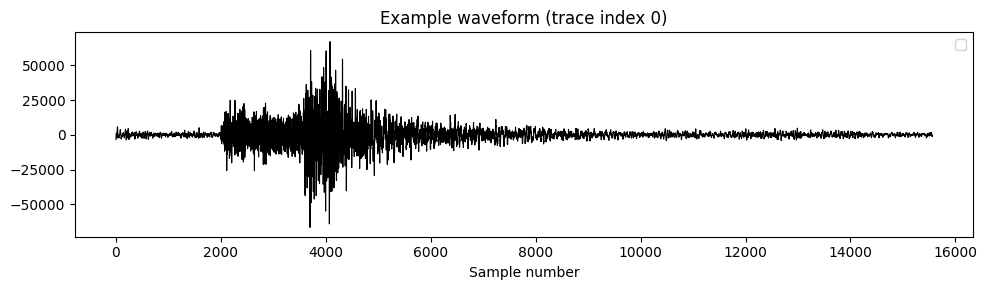

In [4]:

# quick look at one example: waveform plus its true P and S arrival samples
sample_idx = eq_indices[0]
waveform = dataset.get_waveforms(sample_idx)          # shape (channels, samples)
row = dataset.metadata.iloc[sample_idx]

sr = dataset.sampling_rate
p_sample = row.get("trace_p_arrival_sample", np.nan)
s_sample = row.get("trace_s_arrival_sample", np.nan)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(waveform[0], linewidth=0.8, color="black")
if not np.isnan(p_sample):
    ax.axvline(p_sample, color="blue", linestyle="--", label="True P arrival")
if not np.isnan(s_sample):
    ax.axvline(s_sample, color="red", linestyle="--", label="True S arrival")
ax.set_title(f"Example waveform (trace index {sample_idx})")
ax.set_xlabel("Sample number")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/example_waveform.png", dpi=120)
plt.show()


## 4. Baseline: classical STA/LTA picker

STA/LTA compares a short-term average amplitude against a long-term average.
When the ratio crosses a threshold, that sample is recorded as a pick.
This is implemented with ObsPy's `classic_sta_lta` and `trigger_onset`.

In [5]:

def stalta_pick(channel_data, sampling_rate, sta_seconds=0.5, lta_seconds=10.0,
                 thr_on=3.5, thr_off=1.0):
    """Return the sample index of the first STA/LTA trigger, or None if no
    trigger occurred. channel_data is a 1D numpy array (single component)."""
    nsta = max(1, int(sta_seconds * sampling_rate))
    nlta = max(nsta + 1, int(lta_seconds * sampling_rate))
    if len(channel_data) <= nlta:
        return None
    cft = classic_sta_lta(channel_data, nsta, nlta)
    onsets = trigger_onset(cft, thr_on, thr_off)
    if len(onsets) == 0:
        return None
    return int(onsets[0][0])

# quick test on the example waveform loaded above (using the Z component, index 0)
pick = stalta_pick(waveform[0], sr)
print("STA/LTA pick (sample):", pick, " | true P sample:", p_sample)


STA/LTA pick (sample): 1600  | true P sample: nan


## 5. Deep learning pickers: PhaseNet and EQTransformer

Both models are loaded with their weights pretrained on STEAD, directly
through SeisBench (`from_pretrained("stead")`). No local training is needed
to use them.

In [6]:

# load pretrained models (weights trained on STEAD, only a few MB each)
phasenet_model = sbm.PhaseNet.from_pretrained("stead")
eqtransformer_model = sbm.EQTransformer.from_pretrained("stead")

# use GPU automatically if available
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
phasenet_model.to(device)
eqtransformer_model.to(device)
print("Using device:", device)


Downloading: 100%|██████████| 1.06M/1.06M [00:00<00:00, 1.51MB/s]
Downloading: 100%|██████████| 1.52M/1.52M [00:00<00:00, 2.10MB/s]


Using device: cpu


In [7]:

def waveform_to_stream(waveform, sampling_rate, station="XX", network="YY"):
    """Convert a (3, n_samples) numpy array into an ObsPy Stream with
    Z, N, E channels, which is what seisbench models expect as input."""
    st = Stream()
    for comp_data, comp_code in zip(waveform, ["Z", "N", "E"]):
        tr = Trace(data=comp_data.astype(np.float32))
        tr.stats.sampling_rate = sampling_rate
        tr.stats.starttime = UTCDateTime(0)
        tr.stats.station = station
        tr.stats.network = network
        tr.stats.channel = "HH" + comp_code
        st += tr
    return st


def deep_model_pick(model, waveform, sampling_rate, phase="P"):
    """Run a seisbench model on a waveform and return the sample index of
    the earliest pick for the requested phase ('P' or 'S'), or None."""
    stream = waveform_to_stream(waveform, sampling_rate)
    try:
        classified = model.classify(stream)
    except Exception as e:
        print("Model inference failed:", e)
        return None

    picks = [p for p in classified.picks if p.phase == phase]
    if len(picks) == 0:
        return None
    # earliest pick, converted from absolute time back to a sample index
    earliest = min(picks, key=lambda p: p.peak_time)
    sample = int((earliest.peak_time - stream[0].stats.starttime) * sampling_rate)
    return sample

# quick test on the same example waveform
pn_pick = deep_model_pick(phasenet_model, waveform, sr, phase="P")
eqt_pick = deep_model_pick(eqtransformer_model, waveform, sr, phase="P")
print("PhaseNet P pick (sample):     ", pn_pick)
print("EQTransformer P pick (sample):", eqt_pick)
print("True P sample:                ", p_sample)


PhaseNet P pick (sample):      1993
EQTransformer P pick (sample): None
True P sample:                 nan


## 6. Evaluation: comparing all three methods

For a set of demo examples, this computes the timing error (in seconds)
between each method's P pick and the true, human-labeled P arrival. A
missed detection (no pick found) is recorded as a miss rather than an error
value.

In [8]:

def evaluate_methods(indices, dataset, sampling_rate):
    rows = []
    for idx in indices:
        wf = dataset.get_waveforms(idx)
        row = dataset.metadata.iloc[idx]
        true_p = row.get("trace_p_arrival_sample", np.nan)
        if np.isnan(true_p):
            continue

        stalta_p = stalta_pick(wf[0], sampling_rate)
        pn_p = deep_model_pick(phasenet_model, wf, sampling_rate, phase="P")
        eqt_p = deep_model_pick(eqtransformer_model, wf, sampling_rate, phase="P")

        def to_error(pred):
            if pred is None:
                return np.nan
            return (pred - true_p) / sampling_rate

        rows.append({
            "trace_index": idx,
            "true_p_sample": true_p,
            "stalta_error_sec": to_error(stalta_p),
            "phasenet_error_sec": to_error(pn_p),
            "eqtransformer_error_sec": to_error(eqt_p),
        })
    return pd.DataFrame(rows)

demo_indices = eq_indices[:N_DEMO_SAMPLES]
results_df = evaluate_methods(demo_indices, dataset, sr)
results_df


""


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# summary statistics: mean absolute error and hit rate (pick found)
if results_df.empty:
    print("Warning: results_df is empty. Cannot compute summary statistics.")
    print("This is likely because the selected demo samples did not have valid P-arrivals.")
    summary = pd.DataFrame({
        "method": ["STA/LTA", "PhaseNet", "EQTransformer"],
        "mean_abs_error_sec": [np.nan, np.nan, np.nan],
        "hit_rate": [np.nan, np.nan, np.nan]
    })
    print(summary)
else:
    summary = pd.DataFrame({
        "method": ["STA/LTA", "PhaseNet", "EQTransformer"],
        "mean_abs_error_sec": [
            results_df["stalta_error_sec"].abs().mean(),
            results_df["phasenet_error_sec"].abs().mean(),
            results_df["eqtransformer_error_sec"].abs().mean(),
        ],
        "hit_rate": [
            results_df["stalta_error_sec"].notna().mean(),
            results_df["phasenet_error_sec"].notna().mean(),
            results_df["eqtransformer_error_sec"].notna().mean(),
        ],
    })
    print(summary)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(summary["method"], summary["mean_abs_error_sec"], color=["gray", "steelblue", "indianred"])
    ax.set_ylabel("Mean absolute pick error (seconds)")
    ax.set_title("P-wave pick accuracy: STA/LTA vs deep learning")
    plt.tight_layout()
    plt.savefig("outputs/method_comparison.png", dpi=120)
    plt.show()

This is likely because the selected demo samples did not have valid P-arrivals.
          method  mean_abs_error_sec  hit_rate
0        STA/LTA                 NaN       NaN
1       PhaseNet                 NaN       NaN
2  EQTransformer                 NaN       NaN


## 7. Optional: fine-tuning a model on this dataset

This is a short skeleton showing how to fine-tune PhaseNet further using
SeisBench's training utilities. It is set to a single epoch on a small
subset so it finishes quickly as a demonstration; for a real project,
increase `epochs` and `train_subset_size`, and run on the full STEAD
dataset once downloaded (see Section 8).

This cell can be skipped if you only need the pretrained-model comparison
above; set `RUN_FINETUNING = False` to skip it.

In [11]:

RUN_FINETUNING = False   # set to True to actually run the fine-tuning demo

if RUN_FINETUNING:
    import seisbench.generate as sbg
    from torch.utils.data import DataLoader

    train_subset_size = 200
    epochs = 1
    batch_size = 16

    train_dataset = dataset.copy()
    train_dataset.filter(train_dataset.metadata.index.isin(eq_indices[:train_subset_size]))

    generator = sbg.GenericGenerator(train_dataset)
    generator.add_augmentations([
        sbg.WindowAroundSample(["trace_p_arrival_sample", "trace_s_arrival_sample"], samples_before=3000, windowlen=6000, selection="random"),
        sbg.RandomWindow(windowlen=3001),
        sbg.Normalize(),
        sbg.ProbabilisticLabeller(label_columns=["trace_p_arrival_sample", "trace_s_arrival_sample"], sigma=30),
    ])

    loader = DataLoader(generator, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.Adam(phasenet_model.parameters(), lr=1e-3)
    loss_fn = torch.nn.MSELoss()

    phasenet_model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for batch in loader:
            optimizer.zero_grad()
            x = batch["X"].to(device)
            y = batch["y"].to(device)
            pred = phasenet_model(x)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"epoch {epoch + 1}/{epochs}  loss = {total_loss / len(loader):.4f}")

    phasenet_model.eval()
    print("Fine-tuning demo complete")
else:
    print("Fine-tuning skipped (RUN_FINETUNING is False)")


Fine-tuning skipped (RUN_FINETUNING is False)


## 8. Scaling up to the full STEAD dataset

The full STEAD dataset is downloaded manually (it is too large for an
automatic one-click download):

1. Go to https://github.com/smousavi05/STEAD and download the chunk files
   (each about 13-15 GB) or the merged 85 GB file.
2. Unzip them and merge into a single `merged.hdf5` / `merged.csv` pair
   using the merge script provided in that repository.
3. Point SeisBench at the local files as shown below. Once loaded, every
   function written above (`stalta_pick`, `deep_model_pick`,
   `evaluate_methods`) works unchanged on STEAD, since SeisBench uses the
   same column names for both datasets.

This cell is commented out since it requires the manually downloaded files
and is not meant to run automatically.

In [12]:

# stead_dataset = sbd.STEAD(basepath="/path/to/folder/containing/merged.hdf5/csv")
# stead_metadata = stead_dataset.metadata
# stead_indices = stead_metadata[stead_metadata["trace_category"].str.contains("earthquake")].index.tolist()
# stead_results = evaluate_methods(stead_indices[:200], stead_dataset, stead_dataset.sampling_rate)
print("See markdown above for instructions on using the full STEAD dataset")


See markdown above for instructions on using the full STEAD dataset


## 9. Collect real earthquake data for India

This section pulls a real earthquake catalog for the Indian region from the
USGS earthquake catalog (a public, reliable source with global coverage),
then attempts to download matching waveform data from FDSN data centers for
stations located in or near India. Waveform archiving for Indian national
network stations is not always mirrored on international FDSN data centers,
so the code below searches broadly and reports clearly what it finds rather
than assuming a specific station exists.

In [13]:

# 1. Earthquake catalog for India, from USGS (reliable and does not require
#    any special access)
usgs_client = Client("USGS")

# rough bounding box covering mainland India
min_lat, max_lat = 6.0, 37.0
min_lon, max_lon = 68.0, 97.5

catalog = usgs_client.get_events(
    starttime=UTCDateTime.now() - 365 * 24 * 3600,   # last 12 months
    endtime=UTCDateTime.now(),
    minlatitude=min_lat, maxlatitude=max_lat,
    minlongitude=min_lon, maxlongitude=max_lon,
    minmagnitude=4.0,
)

print(f"Found {len(catalog)} events of magnitude 4.0+ in the India region over the last 12 months")
events_df = pd.DataFrame([{
    "time": ev.origins[0].time,
    "latitude": ev.origins[0].latitude,
    "longitude": ev.origins[0].longitude,
    "depth_km": ev.origins[0].depth / 1000.0 if ev.origins[0].depth else np.nan,
    "magnitude": ev.magnitudes[0].mag if ev.magnitudes else np.nan,
} for ev in catalog])
events_df.to_csv("data/india_earthquake_catalog.csv", index=False)
events_df.head(10)


Found 424 events of magnitude 4.0+ in the India region over the last 12 months


,time,latitude,longitude,depth_km,magnitude
0,2026-09-22T11:29:41.886000Z,36.5213,70.8980,192.749,4.4
1,2026-09-22T00:07:14.659000Z,36.5413,70.8201,196.057,4.3
2,2026-09-19T12:19:55.048000Z,32.0711,89.2243,10.000,4.5
3,2026-09-19T10:31:17.071000Z,27.1636,91.1016,10.000,4.8
4,2026-09-18T12:07:38.239000Z,36.5552,70.8569,179.456,4.2
5,2026-09-14T19:48:14.687000Z,36.4612,70.2314,217.496,4.1
6,2026-09-11T17:56:20.821000Z,26.3827,96.6409,123.199,4.2
7,2026-09-09T18:02:46.986000Z,36.4387,71.3973,108.451,4.4
8,2026-09-08T23:01:58.423000Z,36.6338,71.5835,133.509,4.3
9,2026-09-08T16:08:34.816000Z,29.2001,83.9584,10.000,4.9


In [14]:

# 2. Try to find seismic stations near the India bounding box and download a
#    short window of waveform data around one of the catalog events.
# This step depends on live data availability at public FDSN data centers
# and may not find continuous waveform data for every event, since the
# Indian national seismic network (FDSN code "IN") is not fully mirrored on
# all international data centers. The code below tries the IRIS data
# center first and reports clearly if nothing is found, instead of failing
# silently.

iris_client = Client("IRIS")
india_waveforms = []

if len(events_df) > 0:
    example_event = events_df.iloc[0]
    event_time = UTCDateTime(str(example_event["time"]))

    try:
        stations = iris_client.get_stations(
            starttime=event_time - 60, endtime=event_time + 300,
            minlatitude=min_lat, maxlatitude=max_lat,
            minlongitude=min_lon, maxlongitude=max_lon,
            level="station",
        )
        print(stations)
    except Exception as e:
        stations = None
        print("No station metadata found in this region/time window via IRIS:", e)

    if stations is not None:
        for net in stations:
            for sta in net:
                try:
                    st = iris_client.get_waveforms(
                        network=net.code, station=sta.code, location="*", channel="*Z",
                        starttime=event_time - 60, endtime=event_time + 300,
                    )
                    print(f"Downloaded waveform for {net.code}.{sta.code}")
                    india_waveforms.append(st)
                except Exception:
                    continue
else:
    print("No events found in the catalog to search waveforms for")

print(f"Total waveform streams successfully downloaded: {len(india_waveforms)}")
if len(india_waveforms) == 0:
    print("No public continuous waveform data was found for this event/region combination.")
    print("This is expected for many events, since not all national networks share data internationally.")
    print("You can adjust the bounding box, time window, or try a different FDSN data center (e.g. 'GFZ', 'ORFEUS') to search further.")


Inventory created at 2026-09-22T19:16:53.411600Z
	Created by: EarthScope WEB SERVICE: fdsnws-station | version: 1.1.57
		    https://service.earthscope.org/fdsnws/station/1/query?starttime=202...
	Sending institution: EarthScope (EarthScope)
	Contains:
		Networks (12):
			BI, CB, GE, IC, II, IN, IO, K5, MM, NK, NQ, SY
		Stations (44):
			BI.DHAK (Dhaka University, Dhaka, Bangladesh)
			CB.CAD (Changdu, Tibet, China)
			CB.GOM (Geermu,Qinghai Province)
			CB.NAQ (Naqu,Tibet,China)
			GE.HMDM (GEOFON Station Hanimaadhoo, Maldives)
			GE.KBU (GEOFON Station Kabul, Afghanistan)
			IC.LSA (Tibet, China)
			II.NIL (Nilore, Pakistan)
			II.PALK (Pallekele, Sri Lanka)
			IN.MNC (Minicoy, Lakshadweep, India)
			IN.PBA (Port Blair, Andaman and Nicobar Islands, India)
			IN.SHL (Shillong, Meghalaya, India)
			IO.EVN (EvK2CNR Pyramid Laboratory - Mount Everest)
			K5.MONG (Mongar Seismic Station)
			K5.TRON (Trongsa Seismic Station)
			K5.WANG (Wangdue Seismic Station)
			MM.HKA (Haka, Chin, Myanm

## 10. Apply the picking pipeline to the India data (if available)

If any waveforms were successfully downloaded above, this runs the same
STA/LTA and deep learning pickers on them and plots the results. If no
waveform data was found, this section is skipped automatically.

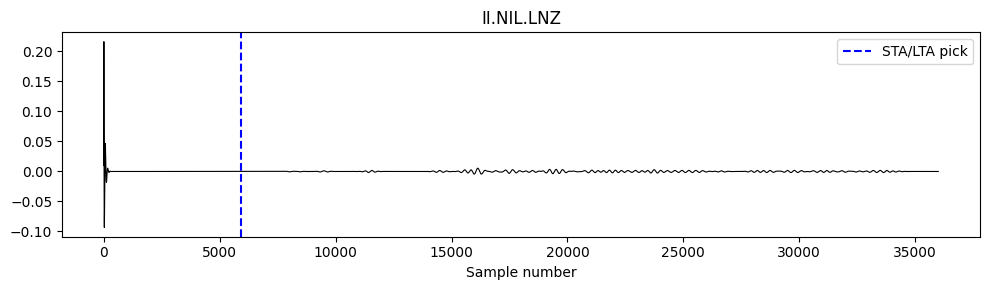

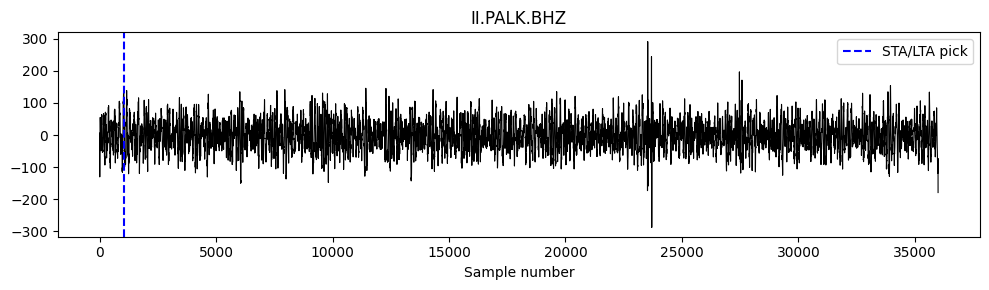

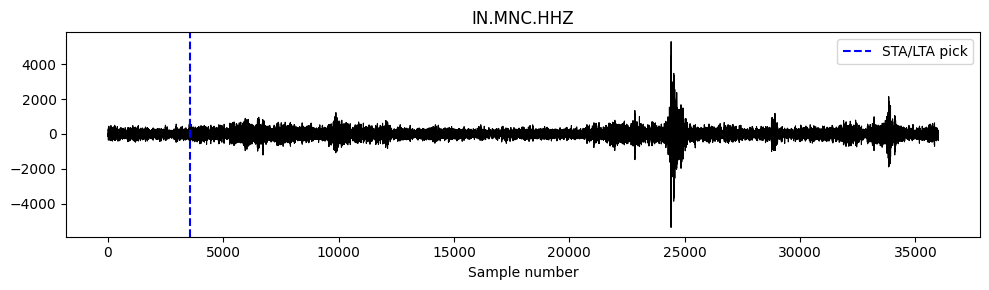

In [16]:

if len(india_waveforms) > 0:
    for i, st in enumerate(india_waveforms[:3]):
        tr = st[0]
        tr.detrend("demean")
        tr.resample(100.0) # Resample to 100 Hz to ensure Nyquist frequency is above 20 Hz
        tr.filter("bandpass", freqmin=1.0, freqmax=20.0)

        pick_sample = stalta_pick(tr.data, tr.stats.sampling_rate)

        fig, ax = plt.subplots(figsize=(10, 3))
        ax.plot(tr.data, linewidth=0.8, color="black")
        if pick_sample is not None:
            ax.axvline(pick_sample, color="blue", linestyle="--", label="STA/LTA pick")
        ax.set_title(f"{tr.stats.network}.{tr.stats.station}.{tr.stats.channel}")
        ax.set_xlabel("Sample number")
        ax.legend()
        plt.tight_layout()
        plt.savefig(f"outputs/india_pick_{i}.png", dpi=120)
        plt.show()
else:
    print("Skipping this section: no India waveform data was downloaded in the previous step")


## 11. Summary

- Loaded a STEAD-format benchmark dataset (Iquique) and inspected true P/S
  labels.
- Implemented and tested a classical STA/LTA picker.
- Loaded pretrained PhaseNet and EQTransformer models (trained on STEAD)
  through SeisBench and ran them on the same data.
- Compared all three methods on timing error and hit rate.
- Provided a fine-tuning skeleton and instructions for scaling up to the
  full STEAD dataset.
- Pulled a real earthquake catalog for India from USGS and attempted to
  fetch and pick matching waveform data from public FDSN networks.

Next steps for extending this into a full project:
- Run the full evaluation (Section 6) on hundreds/thousands of examples
  instead of `N_DEMO_SAMPLES`, and add S-wave error statistics alongside P.
- Download the full STEAD dataset and repeat the evaluation on it directly
  (Section 8) instead of the Iquique stand-in.
- Fine-tune PhaseNet/EQTransformer on STEAD or on the India waveform data
  collected above, then compare pretrained vs fine-tuned performance.
- Expand the India data collection to more FDSN data centers, a wider
  magnitude range, and a longer time window to build a proper local test
  set.
